In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import hashlib
import json
import random
import time
import unicodedata

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    train_test_split
)
from sklearn.utils.class_weight import compute_class_weight

Celda 3 — Configuración general

In [ ]:
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

# ==========================================================
# Dataset original
# ==========================================================

RUTA_DATASET = Path(
    "/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset"
)

CLASES = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

EXTENSIONES_VALIDAS = {
    ".png",
    ".jpg",
    ".jpeg"
}

PORCENTAJE_ENTRENAMIENTO = 0.70
PORCENTAJE_VALIDACION = 0.15
PORCENTAJE_TEST = 0.15

# None = utilizar todas las imágenes disponibles.
MAX_IMAGENES_POR_CLASE = None

# ==========================================================
# Auditoría de duplicados exactos
# ==========================================================

# Calcula el hash SHA-256 de cada archivo y elimina copias exactas
# antes de realizar las particiones.
#
# Esto añade unos minutos, pero evita que una misma imagen pueda
# aparecer con nombres diferentes en entrenamiento y test.

ELIMINAR_DUPLICADOS_EXACTOS = True

# ==========================================================
# CNN propia entrenada desde cero
# ==========================================================

TAMANO_IMAGEN = (256, 256)

TAMANO_LOTE = 16


EPOCAS_MAXIMAS = 30
PACIENCIA_PARADA_TEMPRANA = 6

TASA_APRENDIZAJE = 1e-4


USAR_PRECISION_MIXTA = False

# ==========================================================
# GridSearchCV reducido para Random Forest
# ==========================================================

NUMERO_FOLDS_CV = 3

# GridSearchCV evaluará dos candidatos simultáneamente.
# Si Colab se queda sin RAM, cambia a 1.
N_JOBS_BUSQUEDA = 2

CUADRICULA_HIPERPARAMETROS = {
    "n_estimators": [
        200
    ],

    "max_depth": [
        None,
        25
    ],

    "min_samples_split": [
        2
    ],

    "min_samples_leaf": [
        1
    ],

    "max_features": [
        "sqrt"
    ],

    "class_weight": [
        None,
        "balanced_subsample"
    ],

    "bootstrap": [
        True
    ]
}

# ==========================================================
# Carpeta de guardado
# ==========================================================

RUTA_CARPETA_MODELOS = Path(
    "/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest"
)

RUTA_CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_CNN_MEJOR = (
    RUTA_CARPETA_MODELOS
    / "cnn_propia_mejor.keras"
)

RUTA_CNN_FINAL = (
    RUTA_CARPETA_MODELOS
    / "cnn_propia_final.keras"
)

RUTA_EXTRACTOR = (
    RUTA_CARPETA_MODELOS
    / "extractor_cnn_propia.keras"
)

RUTA_RANDOM_FOREST = (
    RUTA_CARPETA_MODELOS
    / "random_forest_hibrido_gridsearch.joblib"
)

RUTA_FEATURES_ENTRENAMIENTO = (
    RUTA_CARPETA_MODELOS
    / "features_entrenamiento.npy"
)

RUTA_FEATURES_VALIDACION = (
    RUTA_CARPETA_MODELOS
    / "features_validacion.npy"
)

RUTA_FEATURES_TEST = (
    RUTA_CARPETA_MODELOS
    / "features_test.npy"
)

RUTA_ETIQUETAS_ENTRENAMIENTO = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_entrenamiento.npy"
)

RUTA_ETIQUETAS_VALIDACION = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_validacion.npy"
)

RUTA_ETIQUETAS_TEST = (
    RUTA_CARPETA_MODELOS
    / "etiquetas_test.npy"
)

RUTA_RESULTADOS_GRIDSEARCH = (
    RUTA_CARPETA_MODELOS
    / "resultados_gridsearch.csv"
)

RUTA_RESUMEN = (
    RUTA_CARPETA_MODELOS
    / "resumen_modelo_hibrido.txt"
)

RUTA_GRAFICA_ENTRENAMIENTO = (
    RUTA_CARPETA_MODELOS
    / "curvas_entrenamiento_cnn.png"
)

RUTA_MATRIZ_CONFUSION_CNN = (
    RUTA_CARPETA_MODELOS
    / "matriz_confusion_cnn.csv"
)

RUTA_MATRIZ_CONFUSION_HIBRIDO = (
    RUTA_CARPETA_MODELOS
    / "matriz_confusion_hibrido.csv"
)

RUTA_COMPARACION = (
    RUTA_CARPETA_MODELOS
    / "comparacion_cnn_vs_hibrido.csv"
)

# ==========================================================
# Resumen de GridSearchCV
# ==========================================================

NUMERO_COMBINACIONES = len(
    list(
        ParameterGrid(
            CUADRICULA_HIPERPARAMETROS
        )
    )
)

NUMERO_AJUSTES_APROXIMADO = (
    NUMERO_COMBINACIONES
    * NUMERO_FOLDS_CV
    + 1
)

print("Dataset:")
print(RUTA_DATASET)

print("\nTamaño de imagen:")
print(TAMANO_IMAGEN)

print("\nÉpocas máximas de la CNN:")
print(EPOCAS_MAXIMAS)

print("\nNúmero de combinaciones GridSearchCV:")
print(NUMERO_COMBINACIONES)

print("\nNúmero aproximado de ajustes del Random Forest:")
print(NUMERO_AJUSTES_APROXIMADO)

print("\nCarpeta de guardado:")
print(RUTA_CARPETA_MODELOS)

Dataset:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Tamaño de imagen:
(256, 256)

Épocas máximas de la CNN:
30

Número de combinaciones GridSearchCV:
4

Número aproximado de ajustes del Random Forest:
13

Carpeta de guardado:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest


Celda 4 — Comprobar GPU, dataset y modelo

In [ ]:
gpus_disponibles = tf.config.list_physical_devices("GPU")

print("GPU disponibles:")
print(gpus_disponibles)

if len(gpus_disponibles) == 0:
    print("\nAVISO: no se ha detectado ninguna GPU.")
    print("El entrenamiento será considerablemente más lento.")

    tf.keras.mixed_precision.set_global_policy(
        "float32"
    )

elif USAR_PRECISION_MIXTA:
    print("\nGPU detectada correctamente.")
    print("Se activará mixed_float16.")

    tf.keras.mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:
    print("\nGPU detectada correctamente.")
    print("Se mantendrá float32.")

    tf.keras.mixed_precision.set_global_policy(
        "float32"
    )


print("\nPolítica numérica activa:")
print(
    tf.keras.mixed_precision.global_policy()
)


if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f"No existe el dataset: {RUTA_DATASET}"
    )


print("\nDataset encontrado:")
print(RUTA_DATASET)

print("\nContenido de la carpeta principal:")

for elemento in sorted(
    RUTA_DATASET.iterdir()
):
    print("-", elemento.name)

GPU disponibles:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

GPU detectada correctamente.
Se mantendrá float32.

Política numérica activa:
<DTypePolicy "float32">

Dataset encontrado:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset

Contenido de la carpeta principal:
- COVID
- COVID.metadata.xlsx
- Lung_Opacity
- Lung_Opacity.metadata.xlsx
- Normal
- Normal.metadata.xlsx
- README.md.txt
- Viral Pneumonia
- Viral Pneumonia.metadata.xlsx


Localizar imagenes

In [ ]:
def normalizar_texto(
    texto
):
    texto = str(
        texto
    )

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(
            caracter
        )
    )

    texto = texto.lower()

    texto = texto.replace(
        "_",
        " "
    )

    texto = texto.replace(
        "-",
        " "
    )

    texto = " ".join(
        texto.split()
    )

    return texto


def resolver_ruta_clase(
    nombre_clase
):
    ruta_exacta = (
        RUTA_DATASET
        / nombre_clase
    )

    if ruta_exacta.exists():
        return ruta_exacta

    nombre_buscado = normalizar_texto(
        nombre_clase
    )

    candidatas = [
        ruta
        for ruta in RUTA_DATASET.iterdir()
        if (
            ruta.is_dir()
            and normalizar_texto(
                ruta.name
            )
            == nombre_buscado
        )
    ]

    if len(candidatas) == 1:
        return candidatas[0]

    print("\nCarpetas disponibles:")

    for ruta in sorted(
        RUTA_DATASET.iterdir()
    ):
        if ruta.is_dir():
            print("-", ruta.name)

    raise FileNotFoundError(
        f"No se ha encontrado una carpeta única "
        f"para la clase: {nombre_clase}"
    )


def listar_imagenes_clase(
    ruta_clase
):
    imagenes = []

    for archivo in ruta_clase.rglob(
        "*"
    ):
        if not archivo.is_file():
            continue

        if archivo.suffix.lower() not in EXTENSIONES_VALIDAS:
            continue

        ruta_minusculas = str(
            archivo
        ).lower()

        if "mask" in ruta_minusculas:
            continue

        imagenes.append(
            archivo
        )

    return sorted(
        set(
            imagenes
        )
    )


def calcular_hash_archivo(
    ruta_archivo
):
    hash_sha256 = hashlib.sha256()

    with open(
        ruta_archivo,
        "rb"
    ) as archivo:
        while True:
            bloque = archivo.read(
                1024 * 1024
            )

            if not bloque:
                break

            hash_sha256.update(
                bloque
            )

    return hash_sha256.hexdigest()

Crear particiones

In [ ]:
print("LOCALIZANDO IMÁGENES")
print("=" * 100)

registros = []


for indice_clase, nombre_clase in enumerate(
    CLASES
):
    ruta_clase = resolver_ruta_clase(
        nombre_clase
    )

    imagenes_clase = listar_imagenes_clase(
        ruta_clase
    )

    print("\nClase:")
    print(nombre_clase)

    print("Ruta:")
    print(ruta_clase)

    print("Imágenes encontradas:")
    print(len(imagenes_clase))

    if len(imagenes_clase) == 0:
        raise ValueError(
            f"No se encontraron imágenes válidas para: {nombre_clase}"
        )

    if (
        MAX_IMAGENES_POR_CLASE is not None
        and len(
            imagenes_clase
        )
        > MAX_IMAGENES_POR_CLASE
    ):
        generador = random.Random(
            SEMILLA
            + indice_clase
        )

        generador.shuffle(
            imagenes_clase
        )

        imagenes_clase = imagenes_clase[
            :MAX_IMAGENES_POR_CLASE
        ]

    for ruta_imagen in imagenes_clase:
        registros.append(
            {
                "ruta": str(
                    ruta_imagen
                ),
                "etiqueta": indice_clase,
                "clase": nombre_clase
            }
        )


df_imagenes = pd.DataFrame(
    registros
)


print("\nTotal inicial de imágenes:")
print(
    len(
        df_imagenes
    )
)


if ELIMINAR_DUPLICADOS_EXACTOS:
    print("\nCalculando hashes SHA-256...")
    print("Este paso puede tardar varios minutos.")

    inicio_hashes = time.time()

    df_imagenes[
        "hash_sha256"
    ] = df_imagenes[
        "ruta"
    ].apply(
        calcular_hash_archivo
    )

    tiempo_hashes = (
        time.time()
        - inicio_hashes
    )

    print(
        "\nTiempo de cálculo de hashes:",
        f"{tiempo_hashes / 60:.2f} minutos"
    )

    conflictos_etiquetas = (
        df_imagenes
        .groupby(
            "hash_sha256"
        )[
            "clase"
        ]
        .nunique()
    )

    conflictos_etiquetas = conflictos_etiquetas[
        conflictos_etiquetas
        > 1
    ]

    if len(
        conflictos_etiquetas
    ) > 0:
        raise ValueError(
            "Existen imágenes idénticas asignadas a clases distintas. "
            "Debes revisar el dataset antes de entrenar."
        )

    numero_antes = len(
        df_imagenes
    )

    df_imagenes = (
        df_imagenes
        .drop_duplicates(
            subset=[
                "hash_sha256"
            ],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )

    numero_despues = len(
        df_imagenes
    )

    print("\nDuplicados exactos eliminados:")
    print(
        numero_antes
        - numero_despues
    )

else:
    print("\nNo se calcularán hashes.")

    df_imagenes[
        "hash_sha256"
    ] = "no_calculado"


df_entrenamiento, df_temporal = train_test_split(
    df_imagenes,
    test_size=(
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    ),
    random_state=SEMILLA,
    shuffle=True,
    stratify=df_imagenes[
        "etiqueta"
    ]
)


proporcion_test_temporal = (
    PORCENTAJE_TEST
    / (
        PORCENTAJE_VALIDACION
        + PORCENTAJE_TEST
    )
)


df_validacion, df_test = train_test_split(
    df_temporal,
    test_size=proporcion_test_temporal,
    random_state=SEMILLA,
    shuffle=True,
    stratify=df_temporal[
        "etiqueta"
    ]
)


df_entrenamiento = (
    df_entrenamiento
    .copy()
    .reset_index(
        drop=True
    )
)

df_validacion = (
    df_validacion
    .copy()
    .reset_index(
        drop=True
    )
)

df_test = (
    df_test
    .copy()
    .reset_index(
        drop=True
    )
)


df_entrenamiento[
    "particion"
] = "entrenamiento"

df_validacion[
    "particion"
] = "validacion"

df_test[
    "particion"
] = "test"


df_particiones = pd.concat(
    [
        df_entrenamiento,
        df_validacion,
        df_test
    ],
    ignore_index=True
)


print("\nPARTICIONES CREADAS")
print("=" * 100)

tabla_distribucion = (
    df_particiones
    .groupby(
        [
            "particion",
            "clase"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(
    tabla_distribucion
)


print("\nTotal por partición:")

print(
    df_particiones[
        "particion"
    ].value_counts()
)


print("\nComprobación de hashes compartidos entre particiones:")

hashes_compartidos = (
    df_particiones
    .groupby(
        "hash_sha256"
    )[
        "particion"
    ]
    .nunique()
)

hashes_compartidos = hashes_compartidos[
    hashes_compartidos
    > 1
]

print(
    len(
        hashes_compartidos
    )
)


if len(
    hashes_compartidos
) > 0:
    raise ValueError(
        "Se han detectado imágenes exactas repetidas "
        "entre particiones."
    )


print("\nParticionado terminado correctamente.")

LOCALIZANDO IMÁGENES

Clase:
COVID
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/COVID
Imágenes encontradas:
3616

Clase:
Normal
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/Normal
Imágenes encontradas:
10192

Clase:
Viral Pneumonia
Ruta:
/content/drive/MyDrive/TFG/COVID-19_Radiography_Dataset/Viral Pneumonia
Imágenes encontradas:
1345

Total inicial de imágenes:
15153

Calculando hashes SHA-256...
Este paso puede tardar varios minutos.

Tiempo de cálculo de hashes: 0.35 minutos

Duplicados exactos eliminados:
54

PARTICIONES CREADAS
clase          COVID  Normal  Viral Pneumonia
particion                                    
entrenamiento   2499    7133              937
test             536    1529              200
validacion       535    1529              201

Total por partición:
particion
entrenamiento    10569
validacion        2265
test              2265
Name: count, dtype: int64

Comprobación de hashes compartidos entre particiones:
0

Particionado

Crear datasets de TensorFlow

El aumento de datos se incorporará dentro de la CNN y solo estará activo durante el entrenamiento. Los datasets de validación y test no se alteran.

In [ ]:
def cargar_imagen_tensorflow(
    ruta,
    etiqueta
):
    contenido = tf.io.read_file(
        ruta
    )

    imagen = tf.io.decode_image(
        contenido,
        channels=1,
        expand_animations=False
    )

    imagen.set_shape(
        [
            None,
            None,
            1
        ]
    )

    imagen = tf.image.resize(
        imagen,
        TAMANO_IMAGEN,
        antialias=True
    )

    imagen = tf.cast(
        imagen,
        tf.float32
    )

    etiqueta = tf.cast(
        etiqueta,
        tf.int64
    )

    return imagen, etiqueta


def crear_dataset_supervisado(
    dataframe,
    entrenamiento=False
):
    rutas = dataframe[
        "ruta"
    ].astype(
        str
    ).to_numpy()

    etiquetas = dataframe[
        "etiqueta"
    ].astype(
        int
    ).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )

    dataset = dataset.map(
        cargar_imagen_tensorflow,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if entrenamiento:
        dataset = dataset.shuffle(
            buffer_size=len(
                dataframe
            ),
            seed=SEMILLA,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        TAMANO_LOTE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


dataset_entrenamiento = crear_dataset_supervisado(
    df_entrenamiento,
    entrenamiento=True
)

dataset_validacion = crear_dataset_supervisado(
    df_validacion,
    entrenamiento=False
)

dataset_test = crear_dataset_supervisado(
    df_test,
    entrenamiento=False
)


y_entrenamiento = df_entrenamiento[
    "etiqueta"
].to_numpy(
    dtype=np.int64
)

y_validacion = df_validacion[
    "etiqueta"
].to_numpy(
    dtype=np.int64
)

y_test = df_test[
    "etiqueta"
].to_numpy(
    dtype=np.int64
)


print("Datasets preparados correctamente.")

print("\nEntrenamiento:")
print(
    len(
        y_entrenamiento
    )
)

print("\nValidación:")
print(
    len(
        y_validacion
    )
)

print("\nTest:")
print(
    len(
        y_test
    )
)

Datasets preparados correctamente.

Entrenamiento:
10569

Validación:
2265

Test:
2265


Asignamos pesos

In [ ]:
clases_presentes = np.unique(
    y_entrenamiento
)


valores_pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases_presentes,
    y=y_entrenamiento
)


pesos_clases = {
    int(
        clase
    ): float(
        peso
    )
    for clase, peso in zip(
        clases_presentes,
        valores_pesos
    )
}


print("Pesos de clase para la CNN:")
print(
    pesos_clases
)

Pesos de clase para la CNN:
{0: 1.4097639055622249, 1: 0.4939015841861769, 2: 3.759871931696905}


Definir bloques auxiliares de la CNN propia

Aqui estan todos los bloques especiales de la red convolucional, son los mismo que la red original

In [ ]:
def bloque_convolucional(
    x,
    filtros,
    repeticiones,
    nombre_bloque
):
    """
    Bloque convolucional residual utilizado por la CNN original.

    Incluye:
    - varias convoluciones 3x3
    - BatchNormalization
    - activación ReLU
    - conexión residual
    - MaxPooling
    - Dropout
    """

    entrada_bloque = x

    for indice in range(
        repeticiones
    ):
        x = tf.keras.layers.Conv2D(
            filters=filtros,
            kernel_size=(
                3,
                3
            ),
            padding="same",
            use_bias=False,
            name=f"{nombre_bloque}_conv_{indice + 1}"
        )(
            x
        )

        x = tf.keras.layers.BatchNormalization(
            name=f"{nombre_bloque}_bn_{indice + 1}"
        )(
            x
        )

        x = tf.keras.layers.Activation(
            "relu",
            name=f"{nombre_bloque}_relu_{indice + 1}"
        )(
            x
        )

    canales_entrada = int(
        entrada_bloque.shape[
            -1
        ]
    )

    if canales_entrada != filtros:
        entrada_bloque = tf.keras.layers.Conv2D(
            filters=filtros,
            kernel_size=(
                1,
                1
            ),
            padding="same",
            use_bias=False,
            name=f"{nombre_bloque}_proyeccion_residual"
        )(
            entrada_bloque
        )

        entrada_bloque = tf.keras.layers.BatchNormalization(
            name=f"{nombre_bloque}_bn_proyeccion"
        )(
            entrada_bloque
        )

    x = tf.keras.layers.Add(
        name=f"{nombre_bloque}_suma_residual"
    )(
        [
            x,
            entrada_bloque
        ]
    )

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{nombre_bloque}_relu_salida"
    )(
        x
    )

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(
            2,
            2
        ),
        name=f"{nombre_bloque}_max_pooling"
    )(
        x
    )

    x = tf.keras.layers.Dropout(
        rate=0.2,
        name=f"{nombre_bloque}_dropout"
    )(
        x
    )

    return x


def bloque_aspp(
    x
):
    """
    Bloque ASPP original.

    Analiza patrones con diferentes campos receptivos
    mediante cinco ramas paralelas.
    """

    canales_entrada = int(
        x.shape[
            -1
        ]
    )

    rama_1 = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            1,
            1
        ),
        padding="same",
        activation="relu",
        name="aspp_conv_1x1"
    )(
        x
    )

    rama_2 = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            3,
            3
        ),
        padding="same",
        dilation_rate=(
            2,
            2
        ),
        activation="relu",
        name="aspp_conv_d2"
    )(
        x
    )

    rama_3 = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            3,
            3
        ),
        padding="same",
        dilation_rate=(
            4,
            4
        ),
        activation="relu",
        name="aspp_conv_d4"
    )(
        x
    )

    rama_4 = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            3,
            3
        ),
        padding="same",
        dilation_rate=(
            6,
            6
        ),
        activation="relu",
        name="aspp_conv_d6"
    )(
        x
    )

    rama_5 = tf.keras.layers.GlobalAveragePooling2D(
        name="aspp_gap"
    )(
        x
    )

    rama_5 = tf.keras.layers.Reshape(
        target_shape=(
            1,
            1,
            canales_entrada
        ),
        name="aspp_gap_reshape"
    )(
        rama_5
    )

    rama_5 = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            1,
            1
        ),
        padding="same",
        activation="relu",
        name="aspp_image_pool_conv"
    )(
        rama_5
    )

    rama_5 = tf.keras.layers.UpSampling2D(
        size=(
            4,
            4
        ),
        interpolation="bilinear",
        name="aspp_upsample"
    )(
        rama_5
    )

    x = tf.keras.layers.Concatenate(
        name="aspp_concat"
    )(
        [
            rama_1,
            rama_2,
            rama_3,
            rama_4,
            rama_5
        ]
    )

    x = tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(
            1,
            1
        ),
        padding="same",
        activation="relu",
        name="aspp_projection"
    )(
        x
    )

    return x


def bloque_squeeze_excitation(
    x
):
    """
    Bloque Squeeze-and-Excitation original.

    Recalibra los 128 canales de salida del bloque ASPP.
    """

    recalibrado = tf.keras.layers.GlobalAveragePooling2D(
        name="se_gap"
    )(
        x
    )

    recalibrado = tf.keras.layers.Dense(
        units=8,
        activation="relu",
        name="se_dense_1"
    )(
        recalibrado
    )

    recalibrado = tf.keras.layers.Dense(
        units=128,
        activation="sigmoid",
        name="se_dense_2"
    )(
        recalibrado
    )

    recalibrado = tf.keras.layers.Reshape(
        target_shape=(
            1,
            1,
            128
        ),
        name="se_reshape"
    )(
        recalibrado
    )

    x = tf.keras.layers.Multiply(
        name="se_scale"
    )(
        [
            x,
            recalibrado
        ]
    )

    return x

Construimos la cnn desde 0

In [ ]:
def construir_modelo(
    numero_clases
):
    """
    Construye exactamente la arquitectura de la CNN propia original.

    Los pesos se inicializan desde cero.
    No se carga el modelo antiguo.
    """

    entrada = tf.keras.layers.Input(
        shape=(
            256,
            256,
            1
        ),
        name="capa_entrada"
    )

    x = tf.keras.layers.Rescaling(
        scale=1.0 / 255.0,
        name="normalizacion_pixeles"
    )(
        entrada
    )

    x = tf.keras.layers.Resizing(
        height=128,
        width=128,
        interpolation="bilinear",
        name="redimensionamiento"
    )(
        x
    )

    x = bloque_convolucional(
        x=x,
        filtros=32,
        repeticiones=4,
        nombre_bloque="bloque1"
    )

    x = bloque_convolucional(
        x=x,
        filtros=64,
        repeticiones=4,
        nombre_bloque="bloque2"
    )

    x = bloque_convolucional(
        x=x,
        filtros=128,
        repeticiones=4,
        nombre_bloque="bloque3"
    )

    x = bloque_convolucional(
        x=x,
        filtros=256,
        repeticiones=4,
        nombre_bloque="bloque4"
    )

    x = bloque_convolucional(
        x=x,
        filtros=512,
        repeticiones=4,
        nombre_bloque="bloque5"
    )

    x = bloque_aspp(
        x
    )

    x = bloque_squeeze_excitation(
        x
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="promedio_global_clasificador"
    )(
        x
    )

    x = tf.keras.layers.Dense(
        units=128,
        activation="relu",
        name="capa_densa_128"
    )(
        x
    )

    x = tf.keras.layers.Dropout(
        rate=0.2,
        name="dropout_clasificador_1"
    )(
        x
    )

    x = tf.keras.layers.Dense(
        units=32,
        activation="relu",
        name="capa_densa_32"
    )(
        x
    )

    x = tf.keras.layers.Dropout(
        rate=0.2,
        name="dropout_clasificador_2"
    )(
        x
    )

    salida = tf.keras.layers.Dense(
        units=numero_clases,
        activation="softmax",
        name="salida_clasificacion"
    )(
        x
    )

    modelo = tf.keras.Model(
        inputs=entrada,
        outputs=salida,
        name="modelo_radiografias_covid_neumonia_normal"
    )

    return modelo


modelo_cnn = construir_modelo(
    numero_clases=len(
        CLASES
    )
)


modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TASA_APRENDIZAJE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)


print("CNN propia original construida desde cero.")

print("\nArquitectura:")
modelo_cnn.summary()

CNN propia original construida desde cero.

Arquitectura:


Model: "modelo_radiografias_covid_neumonia_normal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ capa_entrada        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalizacion_pixe… │ (None, 256, 256,  │          0 │ capa_entrada[0][… │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ redimensionamiento  │ (None, 128, 128,  │          0 │ normalizacion_pi… │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_1      │ (None, 128, 128,  │        288 │ redimensionamien… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_1        │ (None, 128, 128,  │        128 │ bloque1_conv_1[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_1      │ (None, 128, 128,  │          0 │ bloque1_bn_1[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_2      │ (None, 128, 128,  │      9,216 │ bloque1_relu_1[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_2        │ (None, 128, 128,  │        128 │ bloque1_conv_2[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_2      │ (None, 128, 128,  │          0 │ bloque1_bn_2[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_3      │ (None, 128, 128,  │      9,216 │ bloque1_relu_2[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_3        │ (None, 128, 128,  │        128 │ bloque1_conv_3[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_3      │ (None, 128, 128,  │          0 │ bloque1_bn_3[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_4      │ (None, 128, 128,  │      9,216 │ bloque1_relu_3[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_4        │ (None, 128, 128,  │        128 │ bloque1_conv_4[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_proyeccion… │ (None, 128, 128,  │         32 │ redimensionamien… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_4      │ (None, 128, 128,  │          0 │ bloque1_bn_4[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_proyecc… │ (None, 128, 128,  │        128 │ bloque1_proyecci

 Total params: 13,195,083 (50.34 MB)

 Trainable params: 13,185,163 (50.30 MB)

 Non-trainable params: 9,920 (38.75 KB)

Mostramos la cnn

In [ ]:

print("Entrada de la CNN:")
print(
    modelo_cnn.input_shape
)

print("\nSalida de la CNN:")
print(
    modelo_cnn.output_shape
)

print("\nCapa utilizada posteriormente como extractor:")
print(
    "promedio_global_clasificador"
)

print("\nForma del vector extraído:")
print(
    modelo_cnn.get_layer(
        "promedio_global_clasificador"
    ).output.shape
)

Model: "modelo_radiografias_covid_neumonia_normal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ capa_entrada        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalizacion_pixe… │ (None, 256, 256,  │          0 │ capa_entrada[0][… │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ redimensionamiento  │ (None, 128, 128,  │          0 │ normalizacion_pi… │
│ (Resizing)          │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_1      │ (None, 128, 128,  │        288 │ redimensionamien… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_1        │ (None, 128, 128,  │        128 │ bloque1_conv_1[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_1      │ (None, 128, 128,  │          0 │ bloque1_bn_1[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_2      │ (None, 128, 128,  │      9,216 │ bloque1_relu_1[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_2        │ (None, 128, 128,  │        128 │ bloque1_conv_2[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_2      │ (None, 128, 128,  │          0 │ bloque1_bn_2[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_3      │ (None, 128, 128,  │      9,216 │ bloque1_relu_2[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_3        │ (None, 128, 128,  │        128 │ bloque1_conv_3[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_3      │ (None, 128, 128,  │          0 │ bloque1_bn_3[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_conv_4      │ (None, 128, 128,  │      9,216 │ bloque1_relu_3[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_4        │ (None, 128, 128,  │        128 │ bloque1_conv_4[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_proyeccion… │ (None, 128, 128,  │         32 │ redimensionamien… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_relu_4      │ (None, 128, 128,  │          0 │ bloque1_bn_4[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bloque1_bn_proyecc… │ (None, 128, 128,  │        128 │ bloque1_proyecci

 Total params: 13,195,083 (50.34 MB)

 Trainable params: 13,185,163 (50.30 MB)

 Non-trainable params: 9,920 (38.75 KB)

Entrada de la CNN:
(None, 256, 256, 1)

Salida de la CNN:
(None, 3)

Capa utilizada posteriormente como extractor:
promedio_global_clasificador

Forma del vector extraído:
(None, 128)


Preparar callbacks

ModelCheckpoint guarda un estado del modelo durante fit(), mientras que ReduceLROnPlateau reduce la tasa de aprendizaje cuando la métrica deja de mejorar durante varias épocas.

In [ ]:
class MedidorTiempoEpocas(
    tf.keras.callbacks.Callback
):
    def on_train_begin(
        self,
        logs=None
    ):
        self.inicio_entrenamiento = time.time()

    def on_epoch_begin(
        self,
        epoch,
        logs=None
    ):
        self.inicio_epoca = time.time()

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        tiempo_epoca = (
            time.time()
            - self.inicio_epoca
        )

        tiempo_total = (
            time.time()
            - self.inicio_entrenamiento
        )

        print(
            f"\nÉpoca {epoch + 1}: "
            f"{tiempo_epoca / 60:.2f} minutos | "
            f"Acumulado: {tiempo_total / 60:.2f} minutos"
        )


medidor_tiempo = MedidorTiempoEpocas()


callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            RUTA_CNN_MEJOR
        ),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    medidor_tiempo
]


print("Callbacks originales preparados.")

Callbacks originales preparados.


Ebrenamos la cnn

In [ ]:
print("ENTRENANDO LA CNN PROPIA DESDE CERO")
print("=" * 100)

inicio_entrenamiento_cnn = time.time()


historial_cnn = modelo_cnn.fit(
    dataset_entrenamiento,

    validation_data=dataset_validacion,

    epochs=EPOCAS_MAXIMAS,

    class_weight=pesos_clases,

    callbacks=callbacks_cnn,

    verbose=1
)


tiempo_entrenamiento_cnn = (
    time.time()
    - inicio_entrenamiento_cnn
)


modelo_cnn.save(
    str(
        RUTA_CNN_FINAL
    )
)


print("\nENTRENAMIENTO DE LA CNN TERMINADO")
print("=" * 100)

print("\nTiempo total:")
print(
    f"{tiempo_entrenamiento_cnn / 60:.2f} minutos"
)

print("\nCNN final guardada en:")
print(
    RUTA_CNN_FINAL
)

print("\nMejor CNN guardada en:")
print(
    RUTA_CNN_MEJOR
)

ENTRENANDO LA CNN PROPIA DESDE CERO
Epoch 1/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6007 - loss: 0.7712
Epoch 1: val_loss improved from None to 2.29643, saving model to /content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/cnn_propia_mejor.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/cnn_propia_mejor.keras

Época 1: 1.92 minutos | Acumulado: 1.92 minutos
661/661 ━━━━━━━━━━━━━━━━━━━━ 115s 94ms/step - accuracy: 0.6918 - loss: 0.5930 - val_accuracy: 0.2587 - val_loss: 2.2964 - learning_rate: 1.0000e-04
Epoch 2/30
661/661 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8218 - loss: 0.3630
Epoch 2: val_loss improved from 2.29643 to 0.87730, saving model to /content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/cnn_propia_mejor.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/c

Curva de entrenamiento

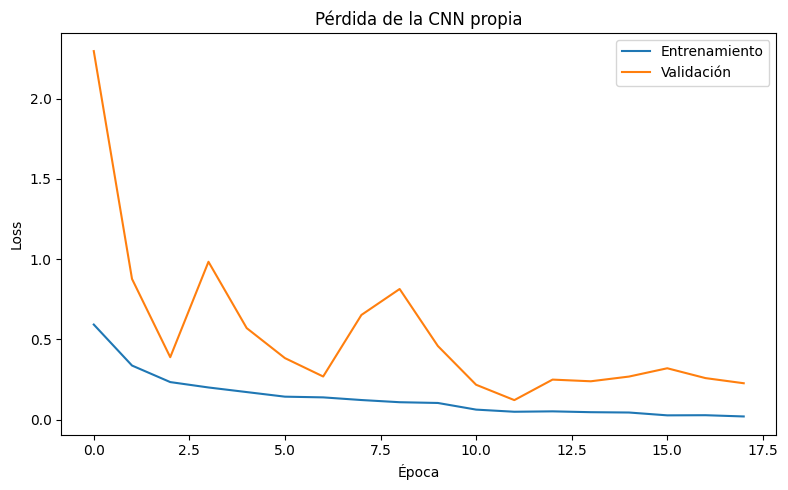

Gráfica guardada en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/curvas_entrenamiento_cnn.png


In [ ]:
figura, eje = plt.subplots(
    figsize=(
        8,
        5
    )
)

eje.plot(
    historial_cnn.history[
        "loss"
    ],
    label="Entrenamiento"
)

eje.plot(
    historial_cnn.history[
        "val_loss"
    ],
    label="Validación"
)

eje.set_title(
    "Pérdida de la CNN propia"
)

eje.set_xlabel(
    "Época"
)

eje.set_ylabel(
    "Loss"
)

eje.legend()

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICA_ENTRENAMIENTO,
    dpi=200
)

plt.show()


print("Gráfica guardada en:")
print(
    RUTA_GRAFICA_ENTRENAMIENTO
)

Recuperar la mejor CNN y crear el extractor congelado

In [ ]:
mejor_modelo_cnn = tf.keras.models.load_model(
    str(
        RUTA_CNN_MEJOR
    ),

    compile=False
)


extractor_caracteristicas = tf.keras.Model(
    inputs=mejor_modelo_cnn.inputs,

    outputs=mejor_modelo_cnn.get_layer(
        "promedio_global_clasificador"
    ).output,

    name="extractor_cnn_propia_original"
)


extractor_caracteristicas.trainable = False


extractor_caracteristicas.save(
    str(
        RUTA_EXTRACTOR
    )
)


print("Extractor congelado creado correctamente.")

print("\nCapa utilizada:")
print(
    "promedio_global_clasificador"
)

print("\nEntrada:")
print(
    extractor_caracteristicas.input_shape
)

print("\nSalida:")
print(
    extractor_caracteristicas.output_shape
)

print("\nGuardado en:")
print(
    RUTA_EXTRACTOR
)

Extractor congelado creado correctamente.

Capa utilizada:
promedio_global_clasificador

Entrada:
(None, 256, 256, 1)

Salida:
(None, 128)

Guardado en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/extractor_cnn_propia.keras


Crear datasets sin shuffle para extraer características

Es importante no barajar las imágenes durante esta fase para que cada vector permanezca alineado con su etiqueta.

In [ ]:

dataset_extraccion_entrenamiento = crear_dataset_supervisado(
    df_entrenamiento,
    entrenamiento=False
)

dataset_extraccion_validacion = crear_dataset_supervisado(
    df_validacion,
    entrenamiento=False
)

dataset_extraccion_test = crear_dataset_supervisado(
    df_test,
    entrenamiento=False
)


print("Datasets de extracción preparados.")

Datasets de extracción preparados.


Extraemos las caracteristicas del modelo cnn recien entrenado

In [ ]:
def extraer_caracteristicas(
    extractor,
    dataset,
    nombre_particion
):
    print(
        f"Extrayendo características de {nombre_particion}..."
    )

    dataset_solo_imagenes = dataset.map(
        lambda imagenes, etiquetas: imagenes,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    inicio = time.time()

    caracteristicas = extractor.predict(
        dataset_solo_imagenes,
        verbose=1
    )

    tiempo = (
        time.time()
        - inicio
    )

    caracteristicas = np.asarray(
        caracteristicas,
        dtype=np.float32
    )

    caracteristicas = np.nan_to_num(
        caracteristicas,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    print(
        f"\n{nombre_particion}:",
        caracteristicas.shape
    )

    print(
        "Tiempo:",
        f"{tiempo / 60:.2f} minutos"
    )

    return caracteristicas, tiempo


X_entrenamiento, tiempo_extraccion_entrenamiento = extraer_caracteristicas(
    extractor_caracteristicas,
    dataset_extraccion_entrenamiento,
    "entrenamiento"
)

X_validacion, tiempo_extraccion_validacion = extraer_caracteristicas(
    extractor_caracteristicas,
    dataset_extraccion_validacion,
    "validación"
)

X_test, tiempo_extraccion_test = extraer_caracteristicas(
    extractor_caracteristicas,
    dataset_extraccion_test,
    "test"
)


np.save(
    RUTA_FEATURES_ENTRENAMIENTO,
    X_entrenamiento
)

np.save(
    RUTA_FEATURES_VALIDACION,
    X_validacion
)

np.save(
    RUTA_FEATURES_TEST,
    X_test
)

np.save(
    RUTA_ETIQUETAS_ENTRENAMIENTO,
    y_entrenamiento
)

np.save(
    RUTA_ETIQUETAS_VALIDACION,
    y_validacion
)

np.save(
    RUTA_ETIQUETAS_TEST,
    y_test
)


print("\nCaracterísticas y etiquetas guardadas.")

Extrayendo características de entrenamiento...
661/661 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step

entrenamiento: (10569, 128)
Tiempo: 0.36 minutos
Extrayendo características de validación...
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

validación: (2265, 128)
Tiempo: 0.06 minutos
Extrayendo características de test...
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

test: (2265, 128)
Tiempo: 0.06 minutos

Características y etiquetas guardadas.


Comprobar los vectores obtenidos

In [ ]:
print("CARACTERÍSTICAS EXTRAÍDAS")
print("=" * 100)

print("\nEntrenamiento:")
print(
    X_entrenamiento.shape
)

print("\nValidación:")
print(
    X_validacion.shape
)

print("\nTest:")
print(
    X_test.shape
)

print("\nNúmero de características por radiografía:")
print(
    X_entrenamiento.shape[
        1
    ]
)

memoria_mb = (
    X_entrenamiento.nbytes
    + X_validacion.nbytes
    + X_test.nbytes
) / (
    1024 ** 2
)

print("\nMemoria ocupada por los vectores:")
print(
    f"{memoria_mb:.2f} MB"
)

CARACTERÍSTICAS EXTRAÍDAS

Entrenamiento:
(10569, 128)

Validación:
(2265, 128)

Test:
(2265, 128)

Número de características por radiografía:
128

Memoria ocupada por los vectores:
7.37 MB


Preparar GridSearchCV

In [ ]:
modelo_rf_base = RandomForestClassifier(
    random_state=SEMILLA,


    n_jobs=1
)


validacion_cruzada = StratifiedKFold(
    n_splits=NUMERO_FOLDS_CV,
    shuffle=True,
    random_state=SEMILLA
)


busqueda_grid = GridSearchCV(
    estimator=modelo_rf_base,

    param_grid=CUADRICULA_HIPERPARAMETROS,

    # Macro F1 da el mismo peso a cada clase.
    scoring="f1_macro",

    cv=validacion_cruzada,

    # Reentrena automáticamente la mejor configuración
    # utilizando todas las características de entrenamiento.
    refit=True,

    n_jobs=N_JOBS_BUSQUEDA,

    pre_dispatch=N_JOBS_BUSQUEDA,

    verbose=2,

    return_train_score=True,

    error_score="raise"
)


print("GridSearchCV preparado.")

print("\nCuadrícula:")
print(
    CUADRICULA_HIPERPARAMETROS
)

print("\nNúmero de combinaciones:")
print(
    NUMERO_COMBINACIONES
)

print("\nNúmero aproximado de ajustes:")
print(
    NUMERO_AJUSTES_APROXIMADO
)

GridSearchCV preparado.

Cuadrícula:
{'n_estimators': [200], 'max_depth': [None, 25], 'min_samples_split': [2], 'min_samples_leaf': [1], 'max_features': ['sqrt'], 'class_weight': [None, 'balanced_subsample'], 'bootstrap': [True]}

Número de combinaciones:
4

Número aproximado de ajustes:
13


Entrenar y optimizar el Random Forest

In [ ]:
print("ENTRENANDO RANDOM FOREST HÍBRIDO")
print("=" * 100)

inicio_gridsearch = time.time()


busqueda_grid.fit(
    X_entrenamiento,
    y_entrenamiento
)


tiempo_gridsearch = (
    time.time()
    - inicio_gridsearch
)


print("\nGRIDSEARCHCV TERMINADO")
print("=" * 100)

print("\nTiempo:")
print(
    f"{tiempo_gridsearch / 60:.2f} minutos"
)

print("\nMejor macro F1 medio en validación cruzada:")
print(
    busqueda_grid.best_score_
)

print("\nMejores hiperparámetros:")
print(
    busqueda_grid.best_params_
)

ENTRENANDO RANDOM FOREST HÍBRIDO
Fitting 3 folds for each of 4 candidates, totalling 12 fits

GRIDSEARCHCV TERMINADO

Tiempo:
1.08 minutos

Mejor macro F1 medio en validación cruzada:
0.9881616448377636

Mejores hiperparámetros:
{'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Guardar resultados del GridSearchCV y recuperar el mejor bosque

In [ ]:
df_resultados_gridsearch = pd.DataFrame(
    busqueda_grid.cv_results_
)

df_resultados_gridsearch = df_resultados_gridsearch.sort_values(
    by="rank_test_score"
)

df_resultados_gridsearch.to_csv(
    RUTA_RESULTADOS_GRIDSEARCH,
    index=False
)


modelo_rf_hibrido = (
    busqueda_grid.best_estimator_
)

mejor_score_cv = (
    busqueda_grid.best_score_
)

mejores_hiperparametros = (
    busqueda_grid.best_params_
)


modelo_rf_hibrido.set_params(
    n_jobs=-1
)


joblib.dump(
    modelo_rf_hibrido,
    RUTA_RANDOM_FOREST
)


print("Resultados guardados en:")
print(
    RUTA_RESULTADOS_GRIDSEARCH
)

print("\nRandom Forest guardado en:")
print(
    RUTA_RANDOM_FOREST
)

print("\nConfiguraciones evaluadas:")

display(
    df_resultados_gridsearch[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
)

Resultados guardados en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/resultados_gridsearch.csv

Random Forest guardado en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/random_forest_hibrido_gridsearch.joblib

Configuraciones evaluadas:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
0,1,0.988162,0.001968,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
1,1,0.988162,0.001968,1.0,"{'bootstrap': True, 'class_weight': None, 'max..."
2,3,0.987653,0.001667,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."
3,3,0.987653,0.001667,1.0,"{'bootstrap': True, 'class_weight': 'balanced_..."


Evaluar la CNN reentrenada

In [ ]:
probabilidades_cnn_validacion = mejor_modelo_cnn.predict(
    dataset_validacion,
    verbose=1
)

probabilidades_cnn_test = mejor_modelo_cnn.predict(
    dataset_test,
    verbose=1
)


predicciones_cnn_validacion = np.argmax(
    probabilidades_cnn_validacion,
    axis=1
)

predicciones_cnn_test = np.argmax(
    probabilidades_cnn_test,
    axis=1
)


accuracy_cnn_validacion = accuracy_score(
    y_validacion,
    predicciones_cnn_validacion
)

macro_f1_cnn_validacion = f1_score(
    y_validacion,
    predicciones_cnn_validacion,
    average="macro"
)

accuracy_cnn_test = accuracy_score(
    y_test,
    predicciones_cnn_test
)

macro_f1_cnn_test = f1_score(
    y_test,
    predicciones_cnn_test,
    average="macro"
)


reporte_cnn_test = classification_report(
    y_test,
    predicciones_cnn_test,
    labels=list(
        range(
            len(
                CLASES
            )
        )
    ),
    target_names=CLASES,
    digits=4,
    zero_division=0
)


print("=" * 100)
print("CNN PROPIA REENTRENADA - TEST")
print("=" * 100)

print("\nAccuracy:")
print(
    accuracy_cnn_test
)

print("\nMacro F1:")
print(
    macro_f1_cnn_test
)

print("\nReporte:")
print(
    reporte_cnn_test
)

142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
CNN PROPIA REENTRENADA - TEST

Accuracy:
0.963355408388521

Macro F1:
0.9544958653317787

Reporte:
                 precision    recall  f1-score   support

          COVID     0.9041    0.9851    0.9429       536
         Normal     0.9952    0.9523    0.9733      1529
Viral Pneumonia     0.9083    0.9900    0.9474       200

       accuracy                         0.9634      2265
      macro avg     0.9359    0.9758    0.9545      2265
   weighted avg     0.9660    0.9634    0.9638      2265



Evaluamos el modelo hibrido

In [ ]:
predicciones_hibrido_validacion = modelo_rf_hibrido.predict(
    X_validacion
)

predicciones_hibrido_test = modelo_rf_hibrido.predict(
    X_test
)


accuracy_hibrido_validacion = accuracy_score(
    y_validacion,
    predicciones_hibrido_validacion
)

macro_f1_hibrido_validacion = f1_score(
    y_validacion,
    predicciones_hibrido_validacion,
    average="macro"
)

accuracy_hibrido_test = accuracy_score(
    y_test,
    predicciones_hibrido_test
)

macro_f1_hibrido_test = f1_score(
    y_test,
    predicciones_hibrido_test,
    average="macro"
)


reporte_hibrido_test = classification_report(
    y_test,
    predicciones_hibrido_test,
    labels=list(
        range(
            len(
                CLASES
            )
        )
    ),
    target_names=CLASES,
    digits=4,
    zero_division=0
)


print("=" * 100)
print("CNN PROPIA + RANDOM FOREST - TEST")
print("=" * 100)

print("\nAccuracy:")
print(
    accuracy_hibrido_test
)

print("\nMacro F1:")
print(
    macro_f1_hibrido_test
)

print("\nReporte:")
print(
    reporte_hibrido_test
)

CNN PROPIA + RANDOM FOREST - TEST

Accuracy:
0.9752759381898455

Macro F1:
0.9643092805778662

Reporte:
                 precision    recall  f1-score   support

          COVID     0.9645    0.9627    0.9636       536
         Normal     0.9799    0.9863    0.9831      1529
Viral Pneumonia     0.9686    0.9250    0.9463       200

       accuracy                         0.9753      2265
      macro avg     0.9710    0.9580    0.9643      2265
   weighted avg     0.9752    0.9753    0.9752      2265



Comparamos los dos modelos

In [ ]:
df_comparacion = pd.DataFrame(
    [
        {
            "modelo": "CNN propia reentrenada",
            "accuracy_validacion": accuracy_cnn_validacion,
            "macro_f1_validacion": macro_f1_cnn_validacion,
            "accuracy_test": accuracy_cnn_test,
            "macro_f1_test": macro_f1_cnn_test
        },

        {
            "modelo": "CNN propia reentrenada + Random Forest",
            "accuracy_validacion": accuracy_hibrido_validacion,
            "macro_f1_validacion": macro_f1_hibrido_validacion,
            "accuracy_test": accuracy_hibrido_test,
            "macro_f1_test": macro_f1_hibrido_test
        }
    ]
)


df_comparacion.to_csv(
    RUTA_COMPARACION,
    index=False
)


print("COMPARACIÓN FINAL")
print("=" * 100)

display(
    df_comparacion
)


print("\nTabla guardada en:")
print(
    RUTA_COMPARACION
)

COMPARACIÓN FINAL


,modelo,accuracy_validacion,macro_f1_validacion,accuracy_test,macro_f1_test
0,CNN propia reentrenada,0.957616,0.945397,0.963355,0.954496
1,CNN propia reentrenada + Random Forest,0.980132,0.973038,0.975276,0.964309



Tabla guardada en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/comparacion_cnn_vs_hibrido.csv


Crear matriz de confusión del híbrido

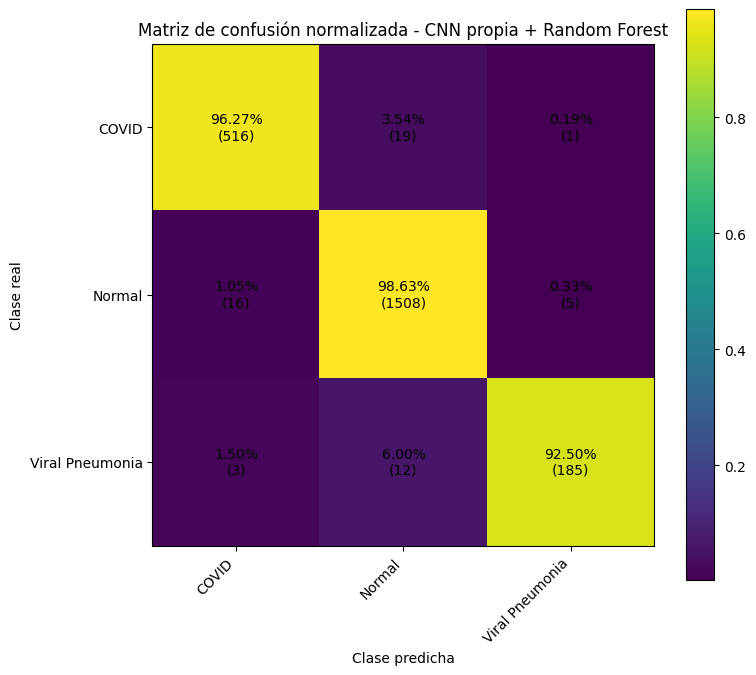

Matriz guardada en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/matriz_confusion_hibrido.csv


In [ ]:
matriz_confusion_hibrido = confusion_matrix(
    y_test,
    predicciones_hibrido_test,
    labels=list(
        range(
            len(
                CLASES
            )
        )
    )
)


matriz_confusion_hibrido_normalizada = (
    matriz_confusion_hibrido.astype(
        "float"
    )
    / np.maximum(
        matriz_confusion_hibrido.sum(
            axis=1
        )[
            :,
            np.newaxis
        ],
        1
    )
)


df_matriz_confusion_hibrido = pd.DataFrame(
    matriz_confusion_hibrido,
    index=CLASES,
    columns=CLASES
)

df_matriz_confusion_hibrido.to_csv(
    RUTA_MATRIZ_CONFUSION_HIBRIDO
)


figura, eje = plt.subplots(
    figsize=(
        8,
        7
    )
)

imagen = eje.imshow(
    matriz_confusion_hibrido_normalizada
)

eje.set_title(
    "Matriz de confusión normalizada - CNN propia + Random Forest"
)

eje.set_xlabel(
    "Clase predicha"
)

eje.set_ylabel(
    "Clase real"
)

eje.set_xticks(
    np.arange(
        len(
            CLASES
        )
    )
)

eje.set_yticks(
    np.arange(
        len(
            CLASES
        )
    )
)

eje.set_xticklabels(
    CLASES,
    rotation=45,
    ha="right"
)

eje.set_yticklabels(
    CLASES
)


for i in range(
    len(
        CLASES
    )
):
    for j in range(
        len(
            CLASES
        )
    ):
        porcentaje = (
            matriz_confusion_hibrido_normalizada[
                i,
                j
            ]
            * 100
        )

        valor_absoluto = (
            matriz_confusion_hibrido[
                i,
                j
            ]
        )

        eje.text(
            j,
            i,
            f"{porcentaje:.2f}%\n({valor_absoluto})",
            ha="center",
            va="center"
        )


plt.colorbar(
    imagen
)

plt.tight_layout()

plt.show()


print("Matriz guardada en:")
print(
    RUTA_MATRIZ_CONFUSION_HIBRIDO
)

Guardamos el resumen completo

In [ ]:
tiempo_extraccion_total = (
    tiempo_extraccion_entrenamiento
    + tiempo_extraccion_validacion
    + tiempo_extraccion_test
)


with open(
    RUTA_RESUMEN,
    "w",
    encoding="utf-8"
) as archivo:
    archivo.write(
        "MODELO HÍBRIDO RIGUROSO: CNN PROPIA REENTRENADA + RANDOM FOREST\n"
    )

    archivo.write(
        "=" * 100
    )

    archivo.write(
        "\n\nLa CNN se entrenó desde cero después de crear las particiones.\n"
    )

    archivo.write(
        "El conjunto de test no intervino en el entrenamiento de la CNN "
        "ni en la selección del Random Forest.\n"
    )

    archivo.write(
        "\nClases:\n"
    )

    for clase in CLASES:
        archivo.write(
            f"- {clase}\n"
        )

    archivo.write(
        "\nTamaño de imagen:\n"
    )

    archivo.write(
        str(
            TAMANO_IMAGEN
        )
    )

    archivo.write(
        "\n\nÉpocas ejecutadas:\n"
    )

    archivo.write(
        str(
            len(
                historial_cnn.history[
                    "loss"
                ]
            )
        )
    )

    archivo.write(
        "\n\nTiempo de entrenamiento de la CNN en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_entrenamiento_cnn
            / 60
        )
    )

    archivo.write(
        "\n\nNúmero de características extraídas por imagen:\n"
    )

    archivo.write(
        str(
            X_entrenamiento.shape[
                1
            ]
        )
    )

    archivo.write(
        "\n\nTiempo de extracción en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_extraccion_total
            / 60
        )
    )

    archivo.write(
        "\n\nNúmero de combinaciones GridSearchCV:\n"
    )

    archivo.write(
        str(
            NUMERO_COMBINACIONES
        )
    )

    archivo.write(
        "\n\nTiempo de GridSearchCV en minutos:\n"
    )

    archivo.write(
        str(
            tiempo_gridsearch
            / 60
        )
    )

    archivo.write(
        "\n\nMejores hiperparámetros:\n"
    )

    archivo.write(
        json.dumps(
            mejores_hiperparametros,
            indent=4,
            default=str
        )
    )

    archivo.write(
        "\n\nCNN REENTRENADA - ACCURACY TEST:\n"
    )

    archivo.write(
        str(
            accuracy_cnn_test
        )
    )

    archivo.write(
        "\n\nCNN REENTRENADA - MACRO F1 TEST:\n"
    )

    archivo.write(
        str(
            macro_f1_cnn_test
        )
    )

    archivo.write(
        "\n\nCNN REENTRENADA - REPORTE TEST:\n"
    )

    archivo.write(
        reporte_cnn_test
    )

    archivo.write(
        "\n\nHÍBRIDO - ACCURACY TEST:\n"
    )

    archivo.write(
        str(
            accuracy_hibrido_test
        )
    )

    archivo.write(
        "\n\nHÍBRIDO - MACRO F1 TEST:\n"
    )

    archivo.write(
        str(
            macro_f1_hibrido_test
        )
    )

    archivo.write(
        "\n\nHÍBRIDO - REPORTE TEST:\n"
    )

    archivo.write(
        reporte_hibrido_test
    )


print("Resumen guardado en:")
print(
    RUTA_RESUMEN
)

Resumen guardado en:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/resumen_modelo_hibrido.txt


In [ ]:
print("ARCHIVOS GENERADOS")
print("=" * 100)

print("\nMejor CNN:")
print(
    RUTA_CNN_MEJOR
)

print("\nCNN final:")
print(
    RUTA_CNN_FINAL
)

print("\nExtractor congelado:")
print(
    RUTA_EXTRACTOR
)

print("\nRandom Forest híbrido:")
print(
    RUTA_RANDOM_FOREST
)

print("\nResultados de GridSearchCV:")
print(
    RUTA_RESULTADOS_GRIDSEARCH
)

print("\nComparación CNN vs. híbrido:")
print(
    RUTA_COMPARACION
)

print("\nResumen:")
print(
    RUTA_RESUMEN
)

print("\nMatriz de confusión del híbrido:")
print(
    RUTA_MATRIZ_CONFUSION_HIBRIDO
)

ARCHIVOS GENERADOS

Mejor CNN:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/cnn_propia_mejor.keras

CNN final:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/cnn_propia_final.keras

Extractor congelado:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/extractor_cnn_propia.keras

Random Forest híbrido:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/random_forest_hibrido_gridsearch.joblib

Resultados de GridSearchCV:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/resultados_gridsearch.csv

Comparación CNN vs. híbrido:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/comparacion_cnn_vs_hibrido.csv

Resumen:
/content/drive/MyDrive/TFG/modelos hibrido cnn propia reentrenada random forest/resumen_modelo_hibrido.txt

Matriz de confusión del híbrido:
/content/drive/MyDrive/TFG/modelos hibrido cnn prop